In [84]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Sessions3.csv")

In [179]:
df

,dcosId,userId,vehicle_model,vehicle_maxChgRate_W,siteId,stationId,connectTime,startChargeTime,Deadline,energyReq_Wh,...,choice,regular,scheduled,cumEnergy_Wh,peakPower_W,power,lastUpdate,year,month,reg-sched
0,24,605,500e,6600,23,7,2020-11-05T10:30:16,2020-11-05T10:31:09,NaN,NaN,...,REGULAR,1,0,3281.0,6335,"[{'power_W': Decimal('6259'), 'timestamp': Dec...",2020-11-05T14:15:06,2020,11,121.0
1,26,486,Model 3,24000,23,3,2020-11-11T07:39:55,2020-11-11T07:39:59,NaN,NaN,...,REGULAR,1,0,33458.0,7005,"[{'power_W': Decimal('0'), 'timestamp': Decima...",2020-11-11T14:30:06,2020,11,147.0
2,30,620,Volt,3600,25,12,2020-11-13T16:19:55,2020-11-13T16:20:06,2020-11-14T04:15:00,18400.0,...,SCHEDULED,0,1,15216.0,3450,"[{'power_W': Decimal('0'), 'timestamp': Decima...",2020-11-14T13:00:08,2020,11,177.0
3,31,618,Bolt,7200,23,6,2020-11-14T23:47:06,2020-11-14T23:47:16,NaN,NaN,...,REGULAR,1,0,14378.0,6889,"[{'power_W': Decimal('6889'), 'timestamp': Dec...",2020-11-15T02:00:07,2020,11,147.0
4,32,623,B-Class Electric Drive,6000,23,9,2020-11-16T11:38:44,2020-11-16T11:42:22,NaN,NaN,...,REGULAR,1,0,12484.0,6852,"[{'power_W': Decimal('6813'), 'timestamp': Dec...",2020-11-16T14:55:07,2020,11,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5609,7489,1165,Model 3,7700,25,16,2024-03-22T09:35:55,2024-03-22T09:37:48,2024-03-22T15:15:00,34544.0,...,SCHEDULED,0,1,33036.0,6732,"[{'power_W': Decimal('6732'), 'timestamp': Dec...",2024-03-22T14:50:05,2024,3,65.0
5610,7490,1258,Mach -E,150000,25,13,2024-03-22T09:47:18,2024-03-22T09:47:35,NaN,NaN,...,REGULAR,1,0,12202.0,6299,"[{'power_W': Decimal('6299'), 'timestamp': Dec...",2024-03-22T11:50:05,2024,3,0.0
5611,7491,1258,Mach -E,150000,25,13,2024-03-22T13:20:15,2024-03-22T13:22:52,2024-03-22T18:30:00,40166.0,...,SCHEDULED,0,1,6658.0,6360,"[{'power_W': Decimal('6360'), 'timestamp': Dec...",2024-03-22T14:30:05,2024,3,0.0
5612,7492,1060,e-Golf,40000,25,11,2024-03-22T18:10:25,2024-03-22T18:11:23,NaN,NaN,...,REGULAR,1,0,9308.0,6633,"[{'power_W': Decimal('6633'), 'timestamp': Dec...",2024-03-22T19:40:05,2024,3,99.0


In [32]:
import re
from decimal import Decimal

# Assuming df['power'].loc[0] contains the string representation of the list of dictionaries
power_string = df['power'].loc[0]

# Extract dictionaries using regular expression
dict_strings = re.findall(r'{[^}]+}', power_string)

# Convert each dictionary string to an actual dictionary
power_list = []
for dict_string in dict_strings:
    dict_obj = eval(dict_string)  # Using eval is potentially unsafe, but in this case, we're using it after a regular expression, which mitigates the risk
    power_list.append(dict_obj)

# Now you have a list of dictionaries
print(type(power_list))


<class 'list'>


In [89]:
import re
from decimal import Decimal

powers = []
timestamps = []

for power_string in df['power']:
    # Extract dictionaries using regular expression
    dict_strings = re.findall(r'{[^}]+}', power_string)
    
    # Convert each dictionary string to an actual dictionary
    power_list = []
    for dict_string in dict_strings:
        dict_obj = eval(dict_string)  # Using eval is potentially unsafe, but in this case, we're using it after a regular expression, which mitigates the risk
        power_list.append(dict_obj)

    for pow_dict in power_list:
        powers.append(float(pow_dict['power_W']) / 1000)
        timestamps.append(int(round(int(pow_dict['timestamp']) / 300.0) * 300))

In [94]:
all_timestamps = np.arange(min(timestamps), max(timestamps), 300)

timestamps.extend(all_timestamps)
powers.extend([0] * len(all_timestamps))



# Create a DataFrame
power_df = pd.DataFrame({'timestamp': timestamps, 'power': powers})

# Aggregate powers for each timestamp
power_df = power_df.groupby('timestamp')['power'].sum().reset_index()

power_df['timestamp'] = pd.to_datetime(power_df['timestamp'], unit='s')

power_df['year'] = power_df['timestamp'].dt.year
power_df['month'] = power_df['timestamp'].dt.month

power_df

,timestamp,power,year,month
0,2020-11-05 18:35:00,6.259,2020,11
1,2020-11-05 18:40:00,6.269,2020,11
2,2020-11-05 18:45:00,6.298,2020,11
3,2020-11-05 18:50:00,6.318,2020,11
4,2020-11-05 18:55:00,6.335,2020,11
...,...,...,...,...
356593,2024-03-27 22:40:00,0.000,2024,3
356594,2024-03-27 22:45:00,0.000,2024,3
356595,2024-03-27 22:50:00,0.000,2024,3
356596,2024-03-27 22:55:00,0.000,2024,3


In [95]:
grouped = power_df.groupby(['year', 'month'])[['timestamp', 'power']].agg(list).reset_index()

In [99]:
grouped

,year,month,timestamp,power
0,2020,11,"[2020-11-05 18:35:00, 2020-11-05 18:40:00, 202...","[6.259, 6.269, 6.298, 6.318, 6.335, 5.809, 3.5..."
1,2020,12,"[2020-12-01 00:00:00, 2020-12-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2021,1,"[2021-01-01 00:00:00, 2021-01-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,2021,2,"[2021-02-01 00:00:00, 2021-02-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,2021,3,"[2021-03-01 00:00:00, 2021-03-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,2021,4,"[2021-04-01 00:00:00, 2021-04-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,2021,5,"[2021-05-01 00:00:00, 2021-05-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 6.756, 6.745, 6.745,..."
7,2021,6,"[2021-06-01 00:00:00, 2021-06-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,2021,7,"[2021-07-01 00:00:00, 2021-07-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,2021,8,"[2021-08-01 00:00:00, 2021-08-01 00:05:00, 202...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


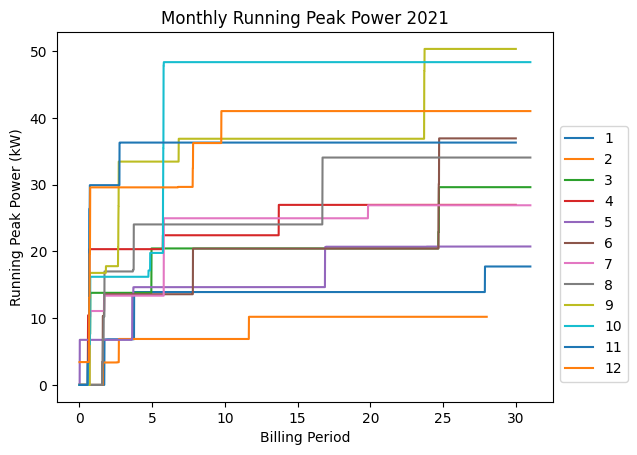

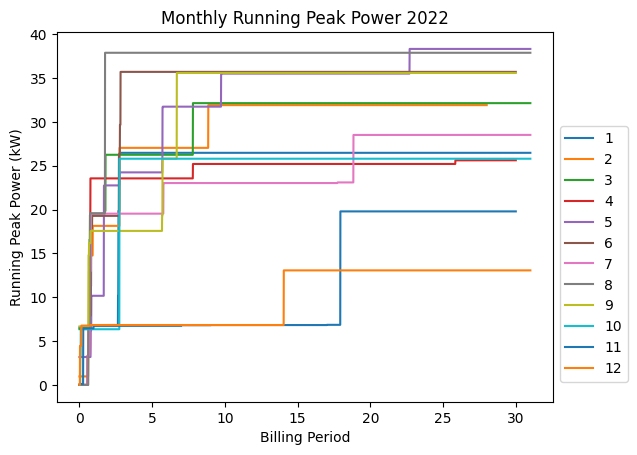

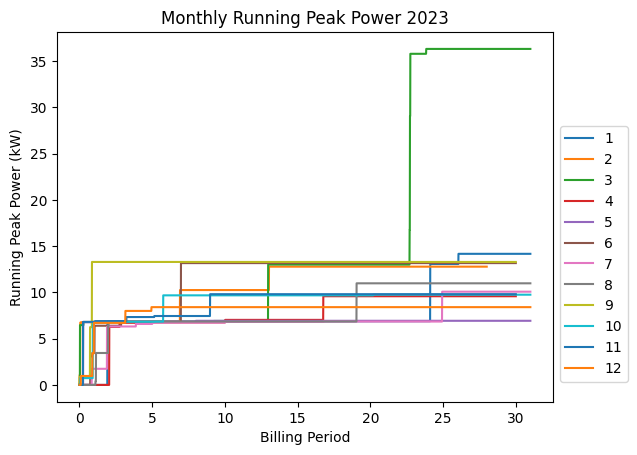

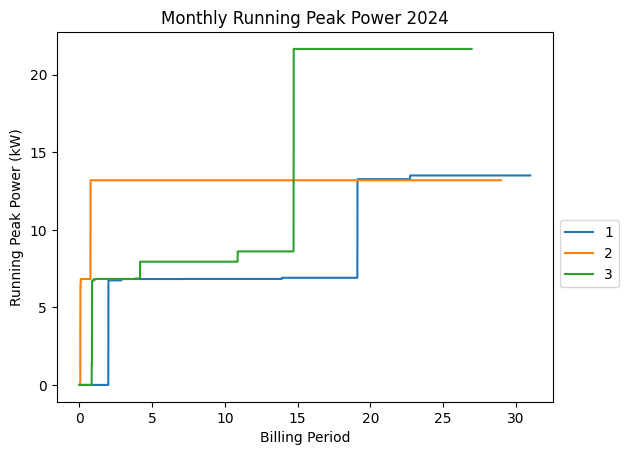

In [126]:
for year in [2021, 2022, 2023, 2024]:
    for index, row in grouped[grouped['year'] == year].iterrows():
        power = row['power']
        running_peak_power = np.maximum.accumulate(power)
        plt.plot(np.arange(len(running_peak_power)) / 288, running_peak_power, label=row['month'])
    
    plt.legend(bbox_to_anchor=(1, 0.4), loc='center left')
    plt.xlabel('Billing Period')
    plt.ylabel('Running Peak Power (kW)')
    plt.title(f"Monthly Running Peak Power {year}")
    plt.show()

$\hat{P}_{peak}$(prices, remaining days, $P_{peak}^{current}$)

In [147]:
maxes = power_df.groupby(['year', 'month'])['power'].agg(max).reset_index()['power']
maxes

/var/folders/_j/vd_r650147l_5pl4bwls0xg00000gn/T/ipykernel_10800/2438216047.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  maxes = power_df.groupby(['year', 'month'])['power'].agg(max).reset_index()['power']


0     14.109
1     13.986
2     17.747
3     10.209
4     29.634
5     26.981
6     20.746
7     36.946
8     26.922
9     34.075
10    50.352
11    48.371
12    36.317
13    41.036
14    26.474
15    31.913
16    32.140
17    25.623
18    38.324
19    35.706
20    28.517
21    37.885
22    35.586
23    25.800
24    19.792
25    13.065
26    14.176
27    12.788
28    36.332
29     9.589
30     6.934
31    13.173
32    10.081
33    10.987
34    13.297
35     9.757
36     9.812
37     8.410
38    13.507
39    13.197
40    21.666
Name: power, dtype: float64

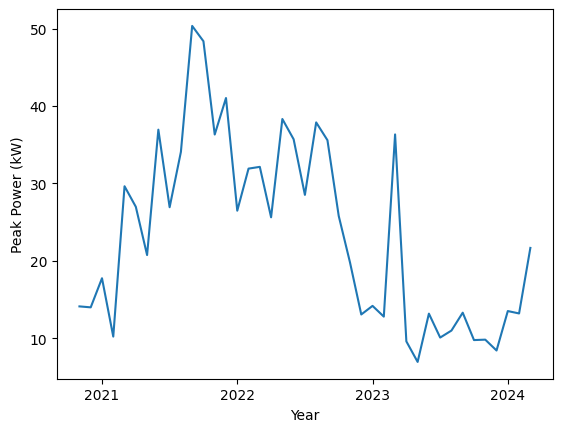

In [164]:
plt.plot(np.arange(2020 + 10/12, 2024 + 1/6, 1/12), maxes)
plt.xticks(np.arange(2021, 2025))
plt.ylabel("Peak Power (kW)")
plt.xlabel('Year');

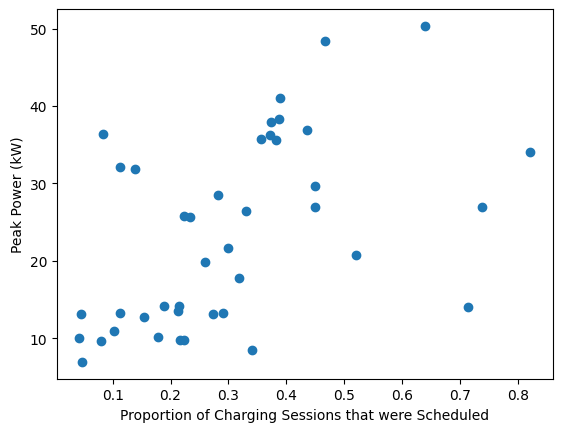

In [165]:
df['year'] = df['connectTime'].astype('datetime64[s]').dt.year
df['month'] = df['connectTime'].astype('datetime64[s]').dt.month


plt.scatter(df.groupby(['year', 'month'])['scheduled'].mean(), maxes)
plt.xlabel('Proportion of Charging Sessions that were Scheduled')
plt.ylabel("Peak Power (kW)");

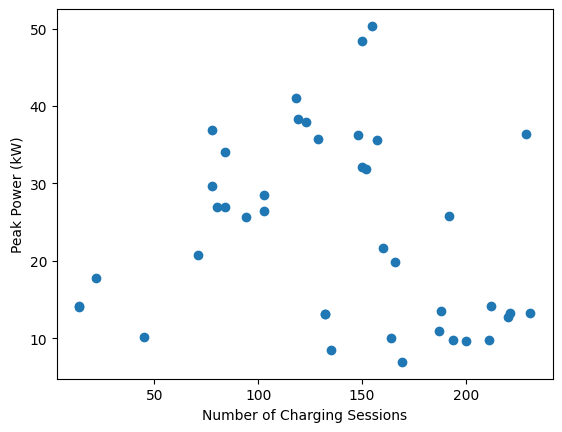

In [166]:
plt.scatter(df.groupby(['year', 'month'])['scheduled'].count(), maxes)
plt.xlabel('Number of Charging Sessions')
plt.ylabel("Peak Power (kW)");

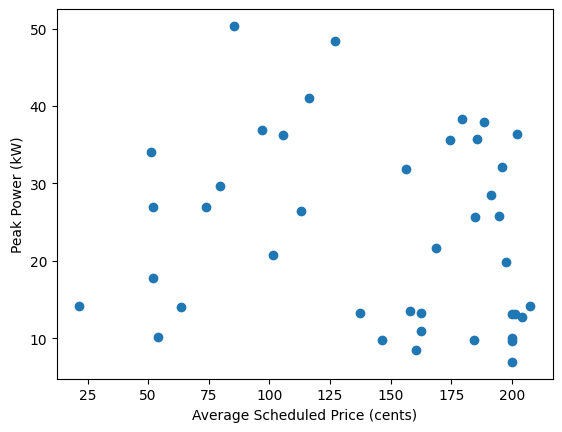

In [174]:
plt.scatter(df.groupby(['year', 'month'])['sch_centsPerHr'].mean(), maxes)
plt.xlabel('Average Scheduled Price (cents)')
plt.ylabel("Peak Power (kW)");

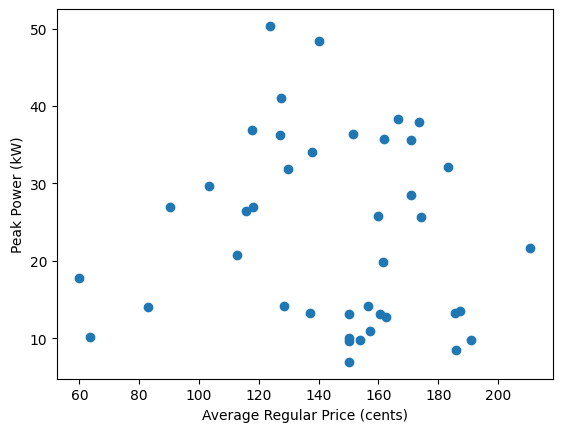

In [175]:
plt.scatter(df.groupby(['year', 'month'])['reg_centsPerHr'].mean(), maxes)
plt.xlabel('Average Regular Price (cents)')
plt.ylabel("Peak Power (kW)");

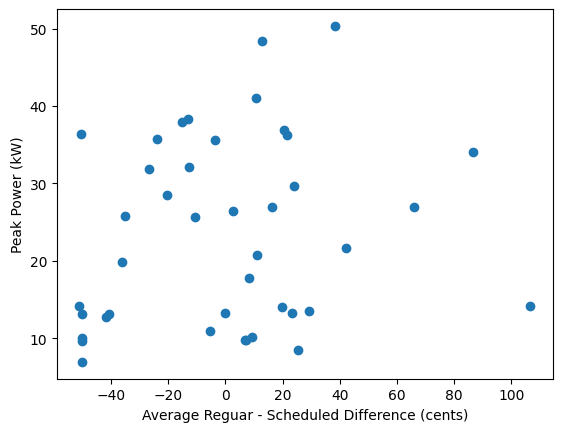

In [178]:
df['reg-sched'] = df['reg_centsPerHr'] - df['sch_centsPerHr']

plt.scatter(df.groupby(['year', 'month'])['reg-sched'].mean(), maxes)
plt.xlabel('Average Reguar - Scheduled Difference (cents)')
plt.ylabel("Peak Power (kW)");